In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

SEED_DIR = Path("../seeds")

csv_files = sorted(SEED_DIR.glob("*.csv"))

print(f"Found {len(csv_files)} CSV files:")
for file in csv_files:
    print(f"  - {file.name}")

datasets = {}

for file in csv_files:
    df = pd.read_csv(file)
    datasets[file.stem] = df
    
    print(f"\n{'=' * 80}")
    print(f"{file.name}")
    print(f"{'=' * 80}")
    print(f"Rows: {len(df):,}")
    print(f"Columns: {len(df.columns):,}")
    
    display(df.head())

Found 3 CSV files:
  - raw_merchants.csv
  - raw_transactions.csv
  - raw_wallets.csv

raw_merchants.csv
Rows: 320
Columns: 6


,merchant_id,merchant_name,mcc,segment,country,onboarded_at
0,m_0001,Alpina Market #001,5812,restaurant,DE,2025-04-06 02:33:27
1,m_0002,Tirol Tankstelle #002,5411,grocery,DE,2025-02-03 18:19:43
2,m_0003,Nordstern Retail #003,5812,restaurant,AT,2025-03-26 21:51:13
3,m_0004,Salzkammergut Store #004,5411,grocery,AT,2025-03-19 05:18:04
4,m_0005,MegaCard Shop #005,5541,fuel,DE,2025-06-24 10:55:54



raw_transactions.csv
Rows: 75,149
Columns: 9


,transaction_id,wallet_id,merchant_id,amount_cents,currency,status,decline_reason,payment_method,created_at
0,tx_00049214,w_004004,m_0084,5444,EUR,authorized,NaN,sdd,2025-06-20 03:53:22
1,tx_00061761,w_005037,m_0127,2597,EUR,authorized,NaN,card,2025-12-21 04:09:05
2,tx_00000922,w_000078,m_0245,4224,EUR,authorized,NaN,sdd,2025-12-31 22:52:40
3,tx_00039467,w_003183,m_0073,4183,EUR,authorized,NaN,sdd,2025-09-15 10:57:32
4,tx_00064192,w_005229,m_0074,3548,EUR,authorized,NaN,sdd,2025-07-23 22:00:48



raw_wallets.csv
Rows: 6,000
Columns: 7


,wallet_id,member_id,country,onboarding_method,marketing_channel,status,created_at
0,w_000001,mem_000001,AT,card,organic,active,2025-06-03 16:48:46
1,w_000002,mem_000002,CH,sdd,search,active,2025-09-03 22:04:54
2,w_000003,mem_000003,AT,sdd,organic,active,2025-11-15 01:09:15
3,w_000004,mem_000004,AT,card,paid_social,active,2025-03-01 08:50:58
4,w_000005,mem_000005,DE,card,referral,active,2025-10-20 23:56:41


In [3]:
def profile_dataset(df):
    profile = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "nulls": df.isna().sum(),
        "null_pct": df.isna().mean() * 100,
        "unique": df.nunique(dropna=True),
    })

    profile["memory_mb"] = df.memory_usage(deep=True).sum() / 1024**2

    return profile.sort_values("null_pct", ascending=False)

In [4]:
for name, df in datasets.items():
    print(f"\n{'=' * 80}")
    print(f"{name.upper()}")
    print(f"{'=' * 80}")
    
    print(f"Shape: {df.shape}")
    print(f"Duplicate rows: {df.duplicated().sum():,}")
    
    display(profile_dataset(df))


RAW_MERCHANTS
Shape: (320, 6)
Duplicate rows: 0


,dtype,non_null,nulls,null_pct,unique,memory_mb
merchant_id,str,320,0,0.000,320,0.094
merchant_name,str,320,0,0.000,320,0.094
mcc,int64,320,0,0.000,7,0.094
segment,str,320,0,0.000,7,0.094
country,str,320,0,0.000,5,0.094
onboarded_at,str,320,0,0.000,320,0.094



RAW_TRANSACTIONS
Shape: (75149, 9)
Duplicate rows: 373


,dtype,non_null,nulls,null_pct,unique,memory_mb
decline_reason,str,7582,67567,89.911,6,32.001
transaction_id,str,75149,0,0.000,74776,32.001
wallet_id,str,75149,0,0.000,6127,32.001
amount_cents,int64,75149,0,0.000,22122,32.001
merchant_id,str,75149,0,0.000,320,32.001
currency,str,75149,0,0.000,1,32.001
status,str,75149,0,0.000,4,32.001
payment_method,str,75149,0,0.000,2,32.001
created_at,str,75149,0,0.000,74612,32.001



RAW_WALLETS
Shape: (6000, 7)
Duplicate rows: 0


,dtype,non_null,nulls,null_pct,unique,memory_mb
member_id,str,5534,466,7.767,5534,2.269
marketing_channel,str,5766,234,3.900,5,2.269
wallet_id,str,6000,0,0.000,6000,2.269
country,str,6000,0,0.000,5,2.269
onboarding_method,str,6000,0,0.000,2,2.269
status,str,6000,0,0.000,3,2.269
created_at,str,6000,0,0.000,6000,2.269


In [5]:
def numeric_profile(df):
    numeric_cols = df.select_dtypes(include=np.number).columns
    
    rows = []

    for col in numeric_cols:
        series = df[col].dropna()
        
        if len(series) == 0:
            continue
        
        q1 = series.quantile(0.25)
        q2 = series.quantile(0.50)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        
        outliers = ((series < lower) | (series > upper)).sum()
        
        rows.append({
            "column": col,
            "count": len(series),
            "mean": series.mean(),
            "std": series.std(),
            "min": series.min(),
            "q1": q1,
            "median": q2,
            "q3": q3,
            "max": series.max(),
            "iqr": iqr,
            "lower_fence": lower,
            "upper_fence": upper,
            "outliers": outliers,
            "outlier_pct": outliers / len(series) * 100,
        })
    
    return pd.DataFrame(rows).sort_values("outlier_pct", ascending=False)

In [6]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    display(df.describe(include="all").T)


RAW_MERCHANTS


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
merchant_id,320,320,m_0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
merchant_name,320,320,Alpina Market #001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mcc,320.000,NaN,NaN,NaN,"5,615.413",328.489,"5,311.000","5,411.000","5,411.000","5,812.000","6,540.000"
segment,320,7,grocery,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,320,5,DE,136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
onboarded_at,320,320,2025-04-06 02:33:27,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN



RAW_TRANSACTIONS


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,75149,74776,tx_00038206,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wallet_id,75149,6127,w_001758,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
merchant_id,75149,320,m_0277,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount_cents,"75,149.000",NaN,NaN,NaN,"9,964.635","14,224.291",501.000,"3,219.000","5,463.000","10,017.000","89,973.000"
currency,75149,1,EUR,75149,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,75149,4,authorized,62077,NaN,NaN,NaN,NaN,NaN,NaN,NaN
decline_reason,7582,6,insufficient_funds,2570,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_method,75149,2,sdd,40024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
created_at,75149,74612,2025-12-15 15:43:40,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN



RAW_WALLETS


,count,unique,top,freq
wallet_id,6000,6000,w_000001,1
member_id,5534,5534,mem_000001,1
country,6000,5,AT,2418
onboarding_method,6000,2,sdd,3289
marketing_channel,5766,5,organic,2034
status,6000,3,active,5191
created_at,6000,6000,2025-06-03 16:48:46,1


In [9]:
def categorical_profile(df, top_n=10):
    categorical_cols = df.select_dtypes(
    include=["object", "str", "category", "bool"]
    ).columns
    
    for col in categorical_cols:
        print(f"\n--- {col} ---")
        print(f"Unique values: {df[col].nunique(dropna=True):,}")
        
        display(
            df[col]
            .value_counts(dropna=False)
            .head(top_n)
            .to_frame("count")
            .assign(
                pct=lambda x: x["count"] / len(df) * 100
            )
        )

In [10]:
for name, df in datasets.items():
    print(f"\n{'=' * 80}")
    print(name.upper())
    print(f"{'=' * 80}")
    
    categorical_profile(df)


RAW_MERCHANTS

--- merchant_id ---
Unique values: 320


,count,pct
merchant_id,,
m_0001,1,0.312
m_0002,1,0.312
m_0003,1,0.312
m_0004,1,0.312
m_0005,1,0.312
m_0006,1,0.312
m_0007,1,0.312
m_0008,1,0.312
m_0009,1,0.312



--- merchant_name ---
Unique values: 320


,count,pct
merchant_name,,
Alpina Market #001,1,0.312
Tirol Tankstelle #002,1,0.312
Nordstern Retail #003,1,0.312
Salzkammergut Store #004,1,0.312
MegaCard Shop #005,1,0.312
Alpina Market #006,1,0.312
PixelTech #007,1,0.312
PixelTech #008,1,0.312
Speck & Co #009,1,0.312



--- segment ---
Unique values: 7


...

,count,pct
marketing_channel,,
organic,2034,33.900
paid_social,1419,23.650
search,975,16.250
referral,857,14.283
partner,481,8.017
NaN,234,3.900



--- status ---
Unique values: 3


,count,pct
status,,
active,5191,86.517
churned,580,9.667
blocked,229,3.817



--- created_at ---
Unique values: 6,000


,count,pct
created_at,,
2025-06-03 16:48:46,1,0.017
2025-09-03 22:04:54,1,0.017
2025-11-15 01:09:15,1,0.017
2025-03-01 08:50:58,1,0.017
2025-10-20 23:56:41,1,0.017
2025-08-31 12:57:53,1,0.017
2025-09-03 04:56:09,1,0.017
2025-06-25 12:08:33,1,0.017
2025-02-05 01:37:27,1,0.017


In [11]:
def plot_numeric_distributions(df, bins=30):
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

    print(f"Found {len(numeric_cols)} numeric columns:")
    print(", ".join(numeric_cols))

    for col in numeric_cols:
        series = df[col].dropna()

        if series.empty:
            continue

        fig, axes = plt.subplots(
            1, 2,
            figsize=(14, 5)
        )

        # Distribution
        sns.histplot(
            series,
            bins=bins,
            kde=True,
            ax=axes[0]
        )

        axes[0].set_title(f"Distribution — {col}")
        axes[0].set_xlabel(col)
        axes[0].set_ylabel("Count")

        # Boxplot
        sns.boxplot(
            x=series,
            ax=axes[1]
        )

        axes[1].set_title(f"Boxplot — {col}")
        axes[1].set_xlabel(col)

        plt.tight_layout()
        plt.show()


RAW_MERCHANTS — NUMERIC DISTRIBUTIONS
Found 1 numeric columns:
mcc


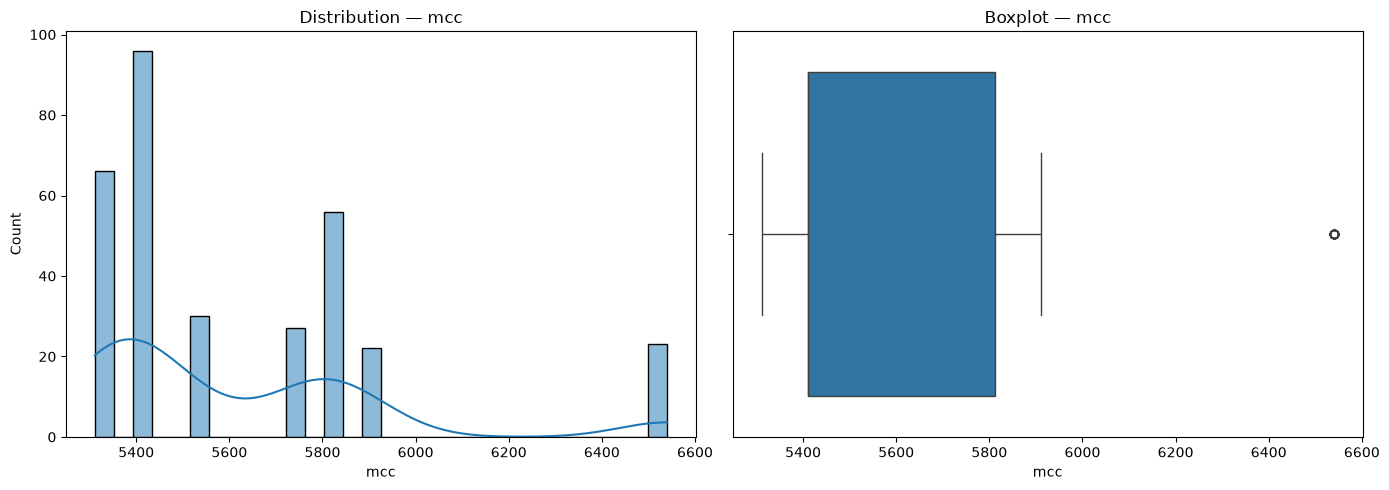


RAW_TRANSACTIONS — NUMERIC DISTRIBUTIONS
Found 1 numeric columns:
amount_cents


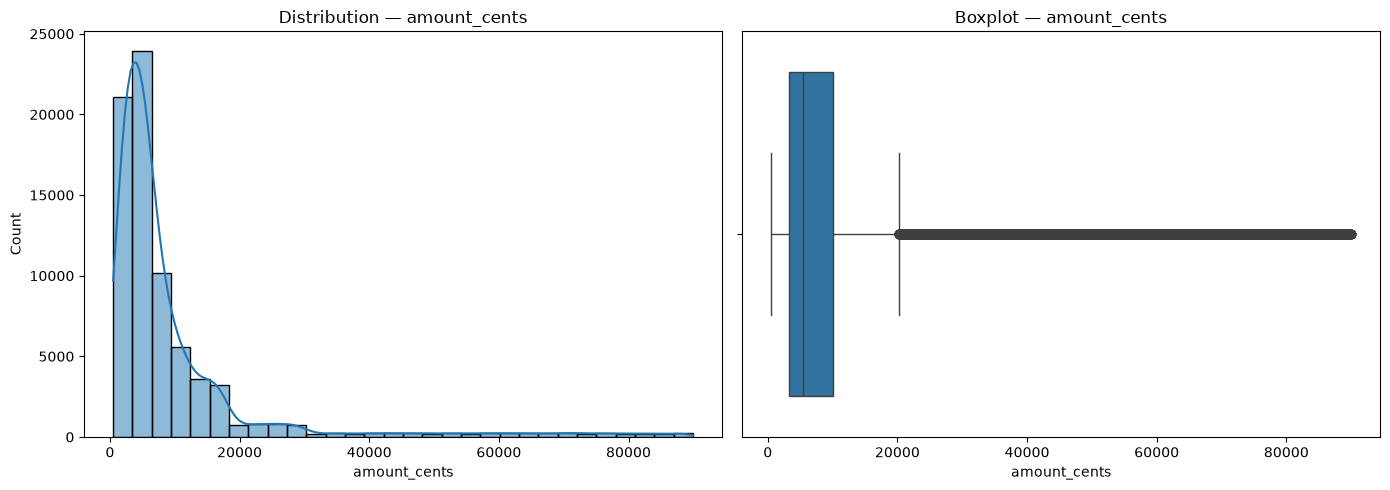


RAW_WALLETS — NUMERIC DISTRIBUTIONS
Found 0 numeric columns:



In [12]:
for name, df in datasets.items():
    print(f"\n{'=' * 80}")
    print(f"{name.upper()} — NUMERIC DISTRIBUTIONS")
    print(f"{'=' * 80}")

    plot_numeric_distributions(df)

In [13]:
def plot_categorical_distributions(df, top_n=15):
    categorical_cols = df.select_dtypes(
        include=["object", "str", "category", "bool"]
    ).columns.tolist()

    print(f"Found {len(categorical_cols)} categorical columns:")
    print(", ".join(categorical_cols))

    for col in categorical_cols:

        # Don't create insane plots for ID-like columns
        n_unique = df[col].nunique(dropna=True)

        if n_unique == 0:
            continue

        if n_unique > 50:
            print(
                f"Skipping {col}: "
                f"{n_unique:,} unique values"
            )
            continue

        counts = (
            df[col]
            .fillna("<NULL>")
            .value_counts()
            .head(top_n)
            .sort_values()
        )

        plt.figure(figsize=(10, 6))

        sns.barplot(
            x=counts.values,
            y=counts.index
        )

        plt.title(f"Value Counts — {col}")
        plt.xlabel("Count")
        plt.ylabel(col)

        plt.tight_layout()
        plt.show()


RAW_MERCHANTS — CATEGORICAL DISTRIBUTIONS
Found 5 categorical columns:
merchant_id, merchant_name, segment, country, onboarded_at
Skipping merchant_id: 320 unique values
Skipping merchant_name: 320 unique values


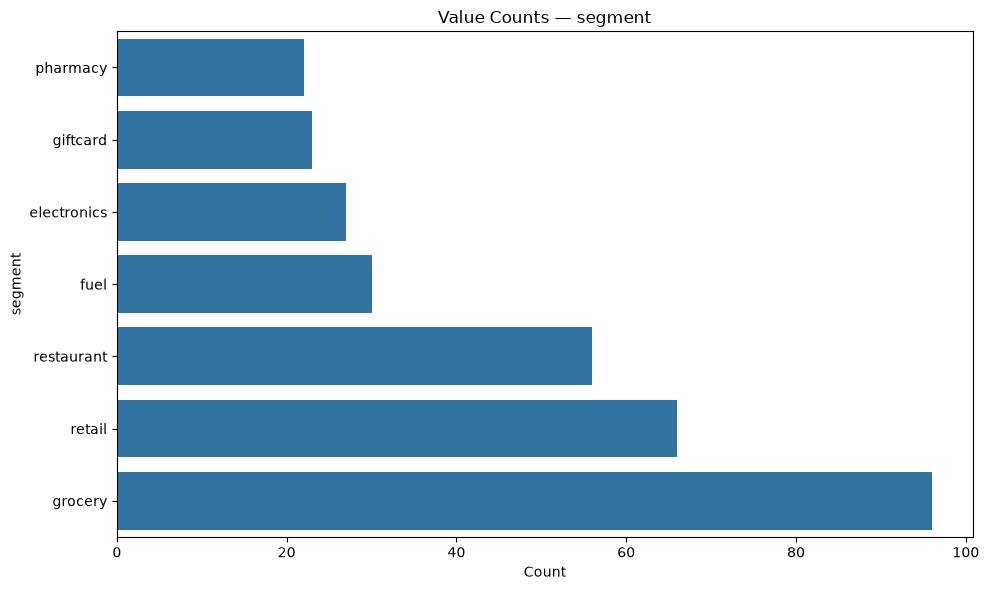

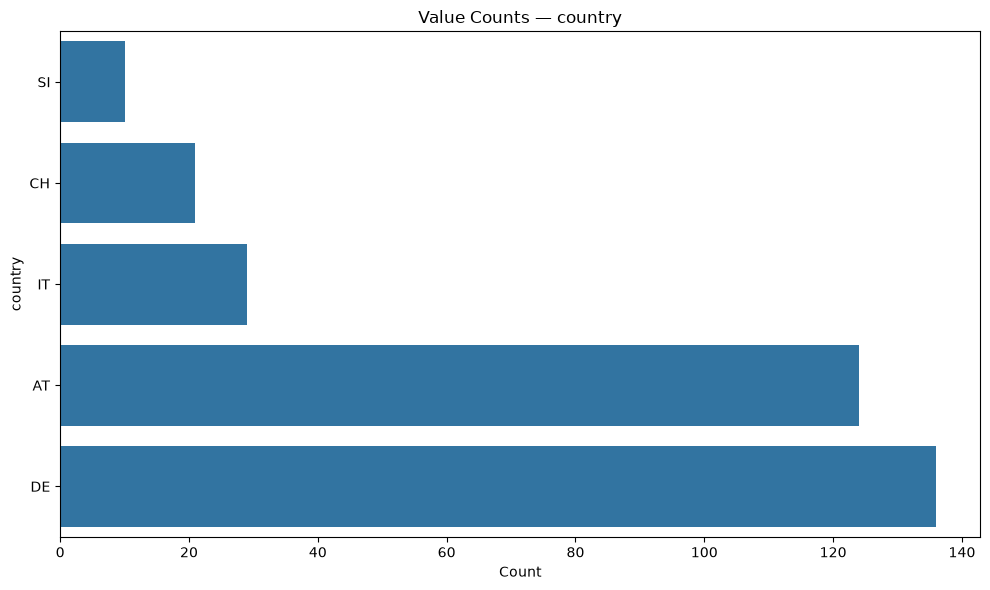

Skipping onboarded_at: 320 unique values

RAW_TRANSACTIONS — CATEGORICAL DISTRIBUTIONS
Found 8 categorical columns:
transaction_id, wallet_id, merchant_id, currency, status, decline_reason, payment_method, created_at
Skipping transaction_id: 74,776 unique values
Skipping wallet_id: 6,127 unique values
Skipping merchant_id: 320 unique values


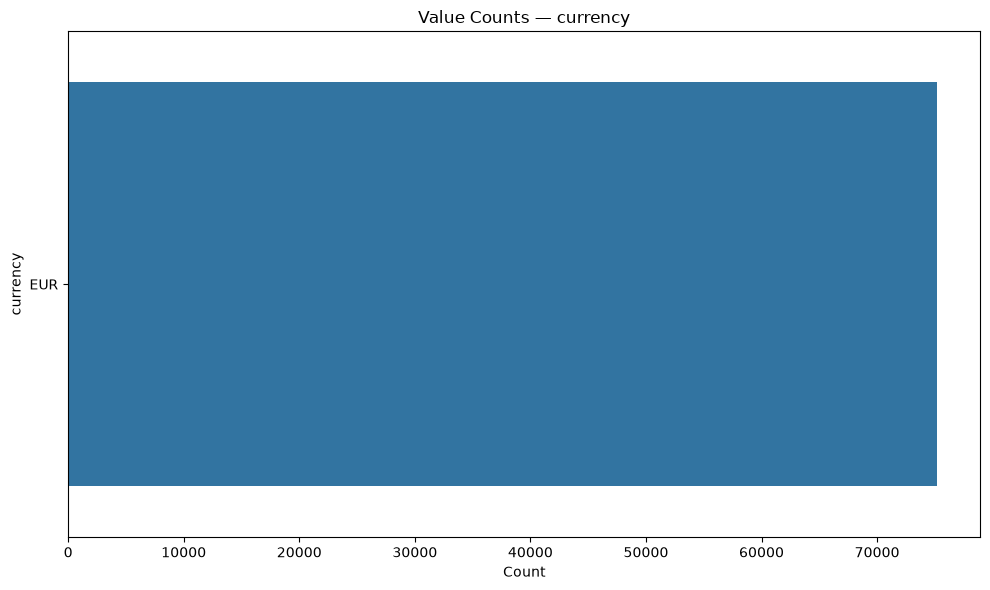

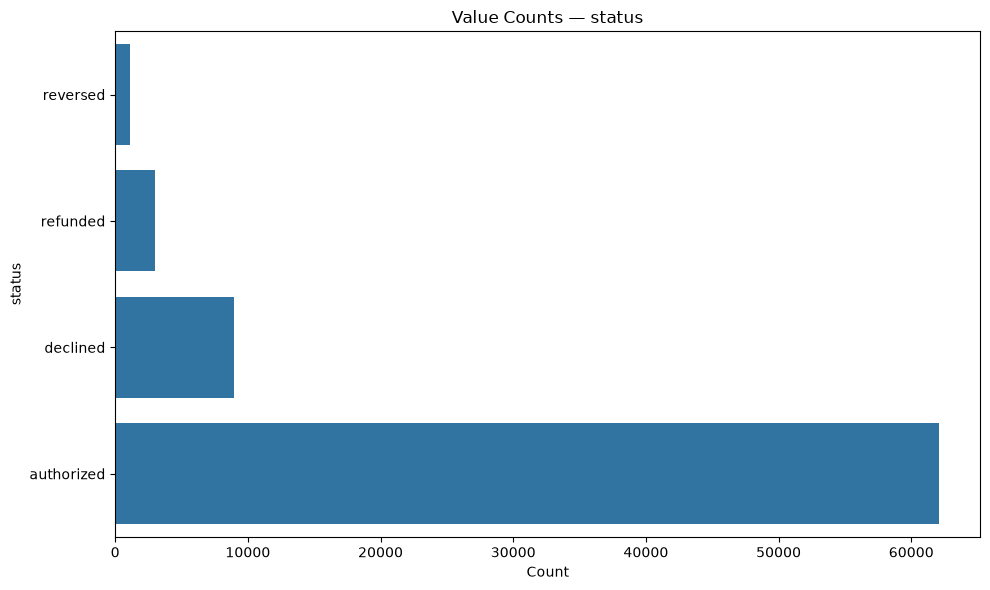

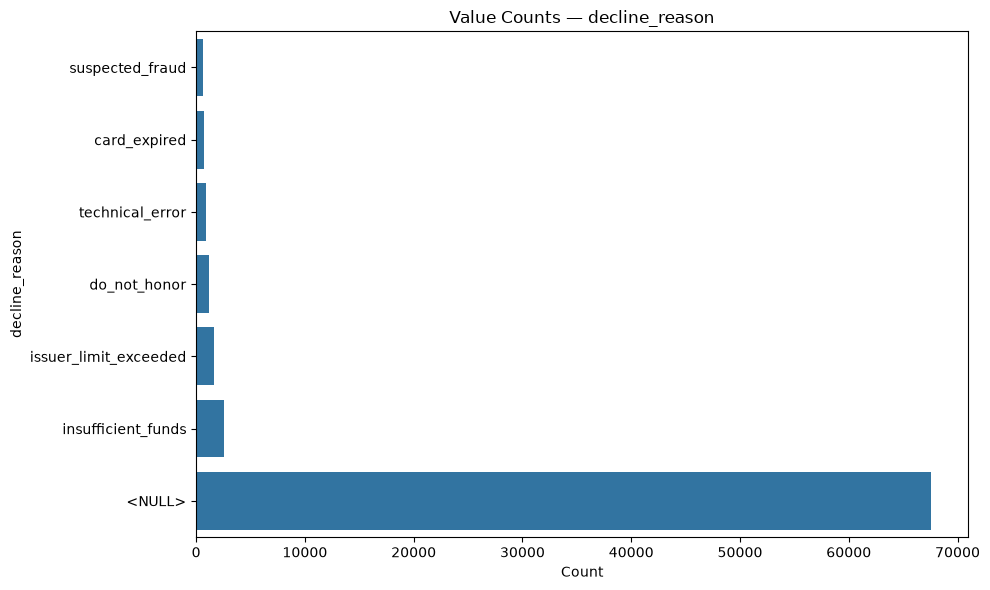

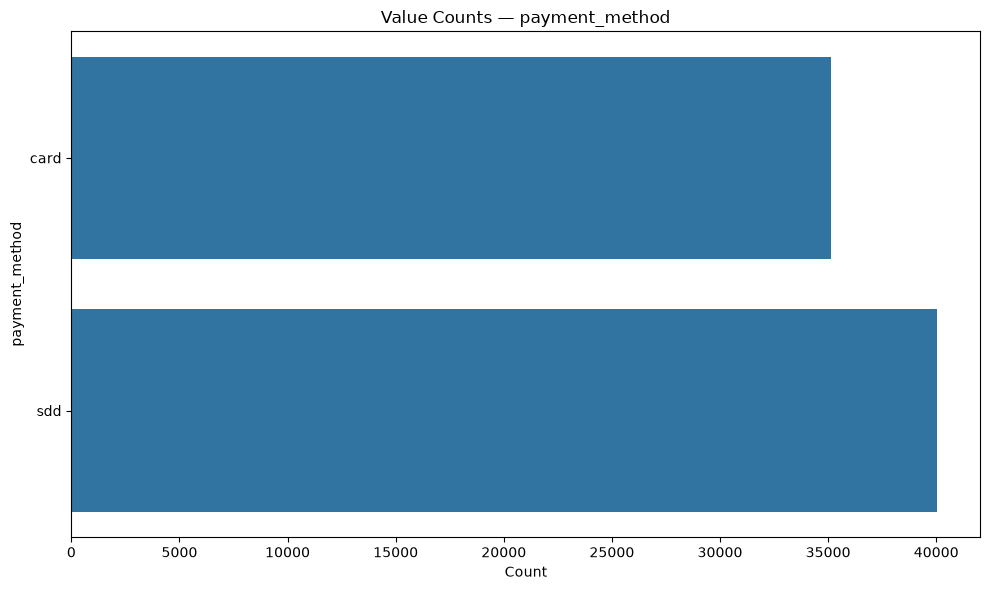

Skipping created_at: 74,612 unique values

RAW_WALLETS — CATEGORICAL DISTRIBUTIONS
Found 7 categorical columns:
wallet_id, member_id, country, onboarding_method, marketing_channel, status, created_at
Skipping wallet_id: 6,000 unique values
Skipping member_id: 5,534 unique values


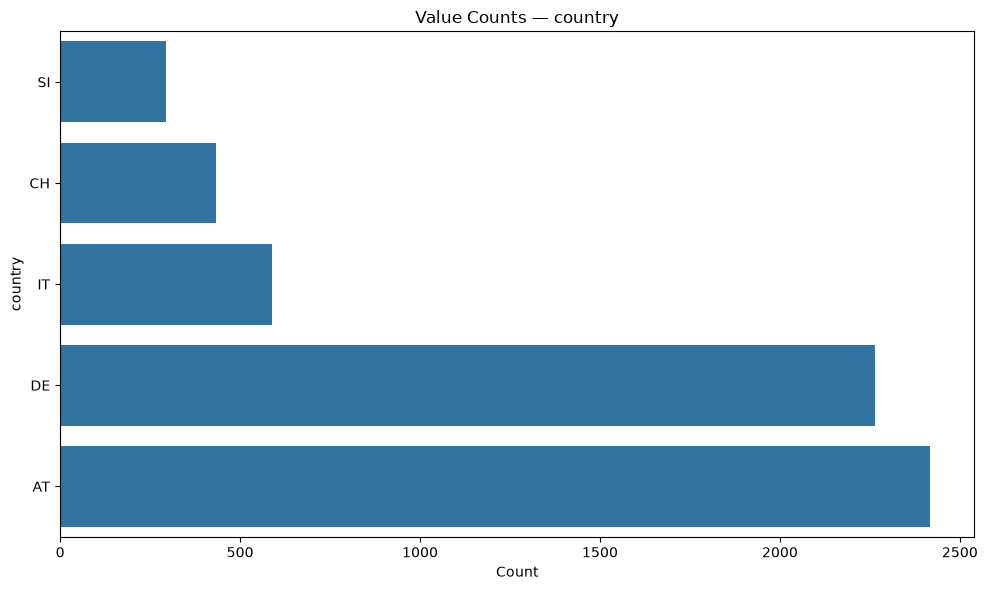

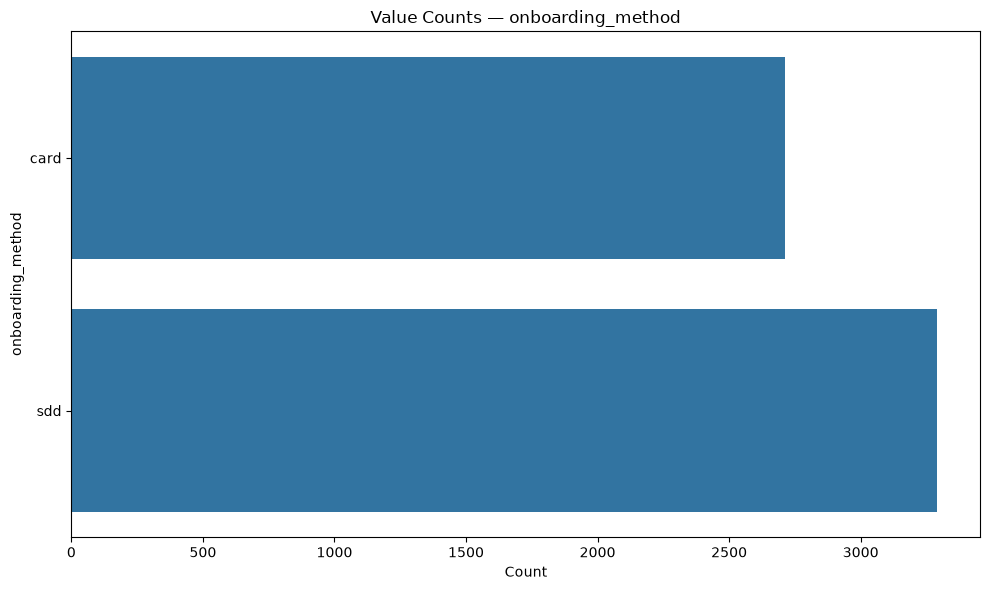

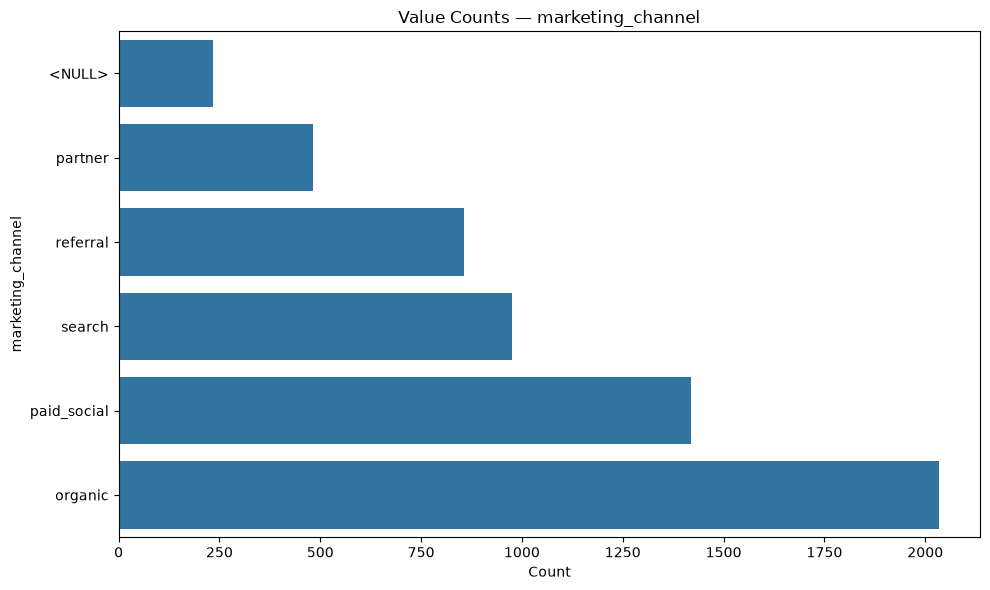

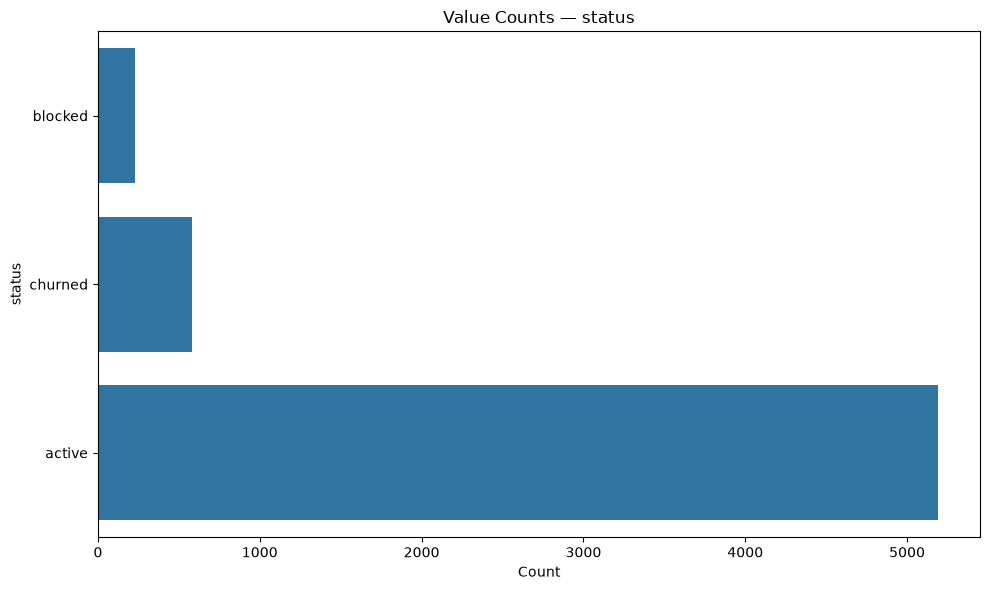

Skipping created_at: 6,000 unique values


In [14]:
for name, df in datasets.items():
    print(f"\n{'=' * 80}")
    print(f"{name.upper()} — CATEGORICAL DISTRIBUTIONS")
    print(f"{'=' * 80}")

    plot_categorical_distributions(df)


####################################################################################################
# EDA: RAW_MERCHANTS
####################################################################################################
Found 1 numeric columns:
mcc


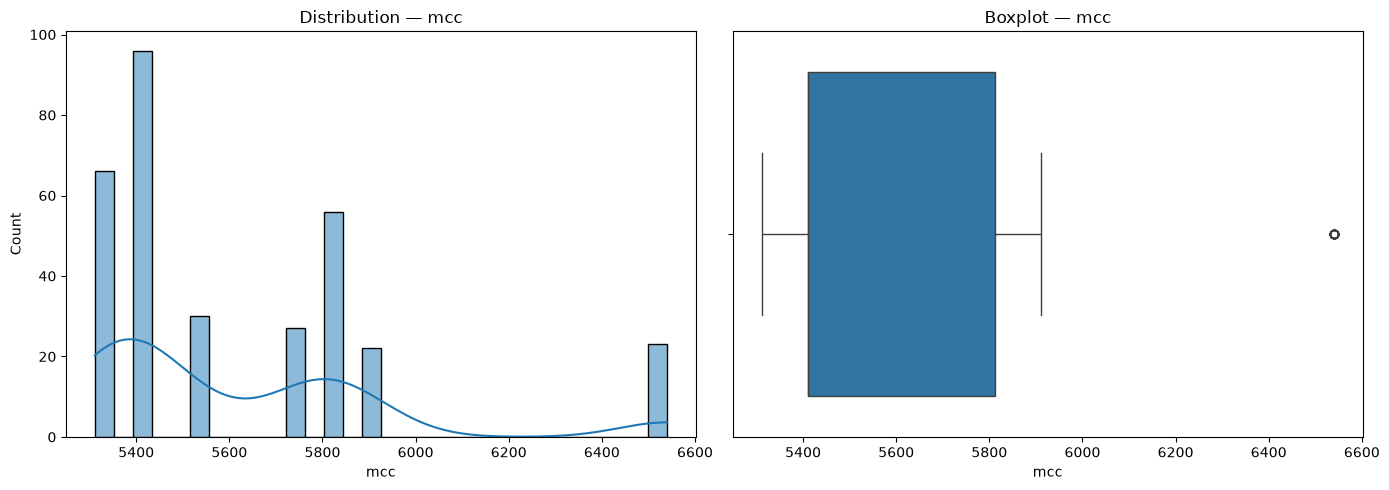

Found 5 categorical columns:
merchant_id, merchant_name, segment, country, onboarded_at
Skipping merchant_id: 320 unique values
Skipping merchant_name: 320 unique values


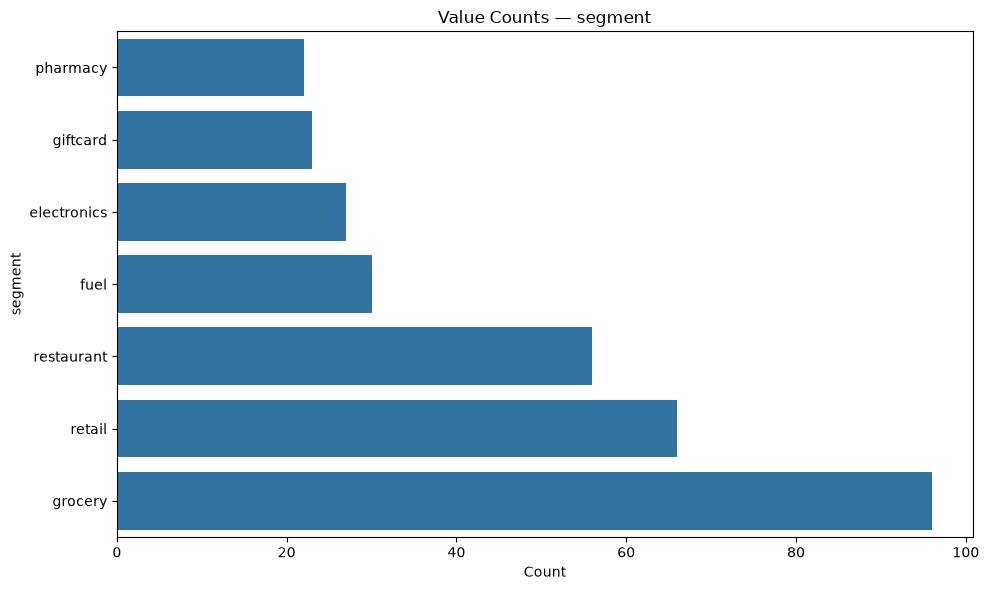

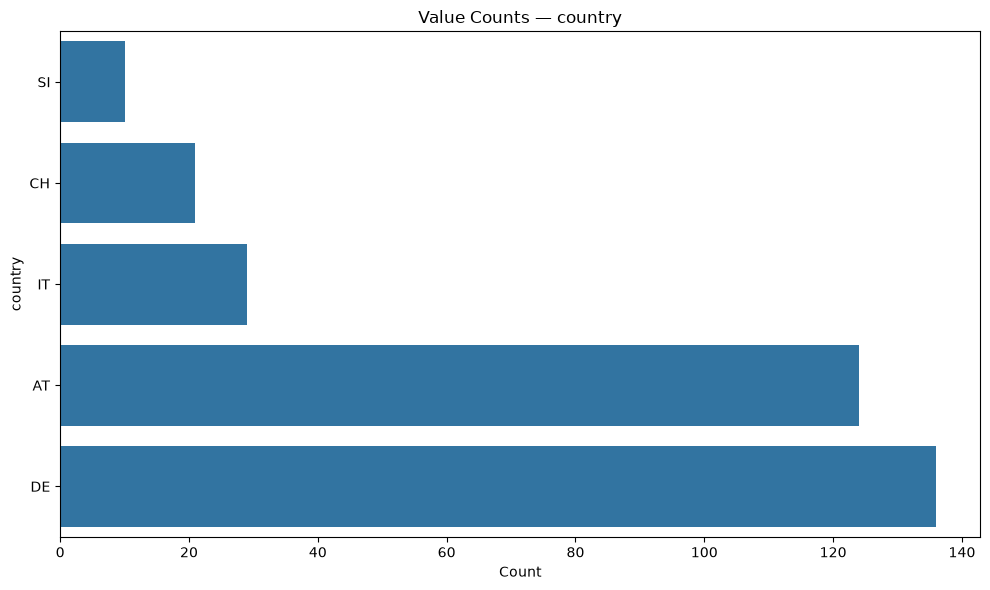

Skipping onboarded_at: 320 unique values

####################################################################################################
# EDA: RAW_TRANSACTIONS
####################################################################################################
Found 1 numeric columns:
amount_cents


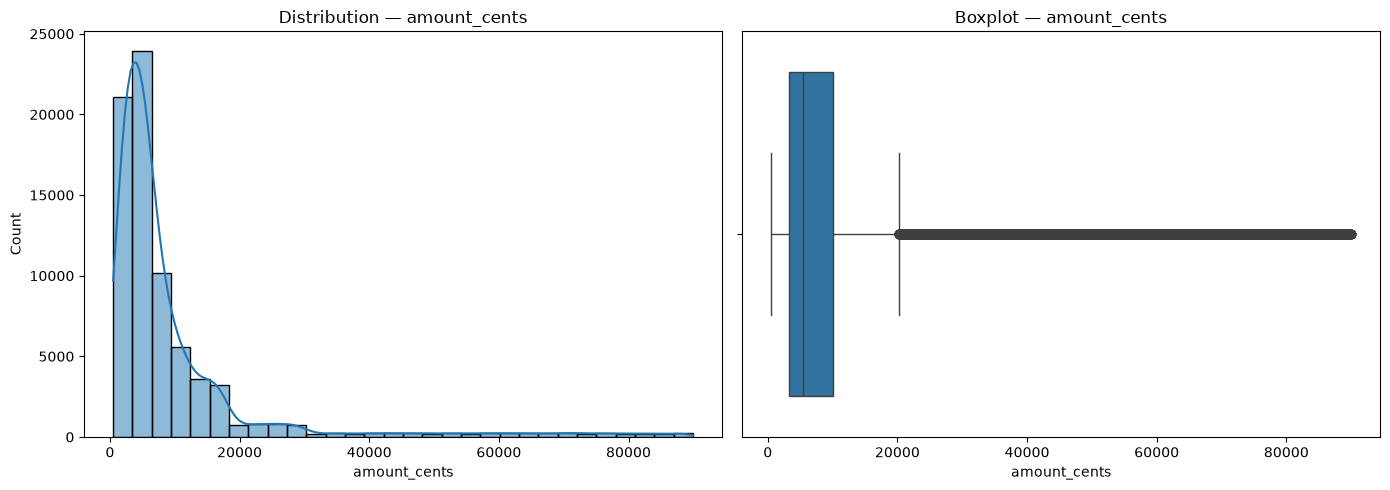

Found 8 categorical columns:
transaction_id, wallet_id, merchant_id, currency, status, decline_reason, payment_method, created_at
Skipping transaction_id: 74,776 unique values
Skipping wallet_id: 6,127 unique values
Skipping merchant_id: 320 unique values


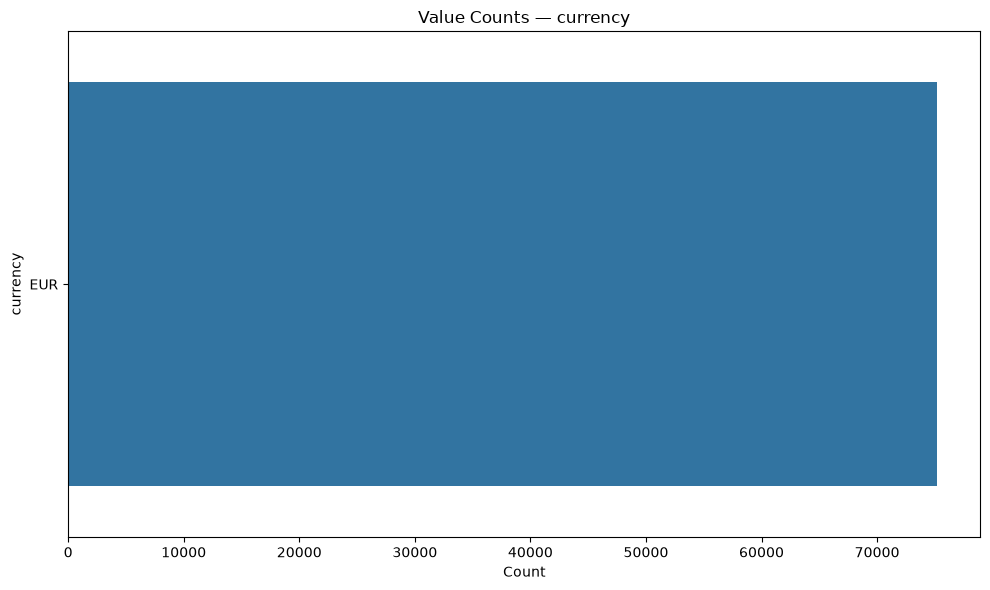

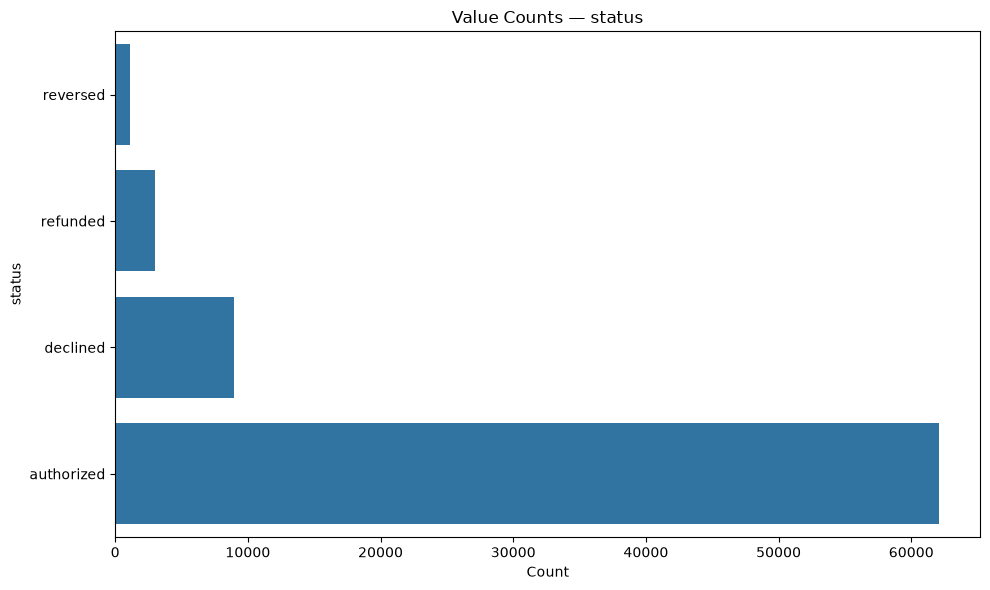

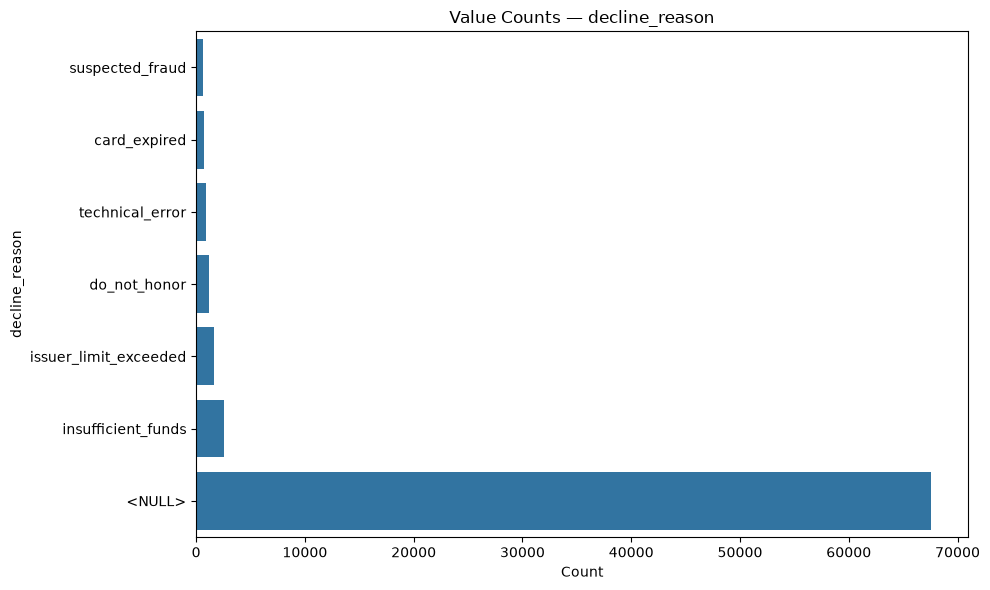

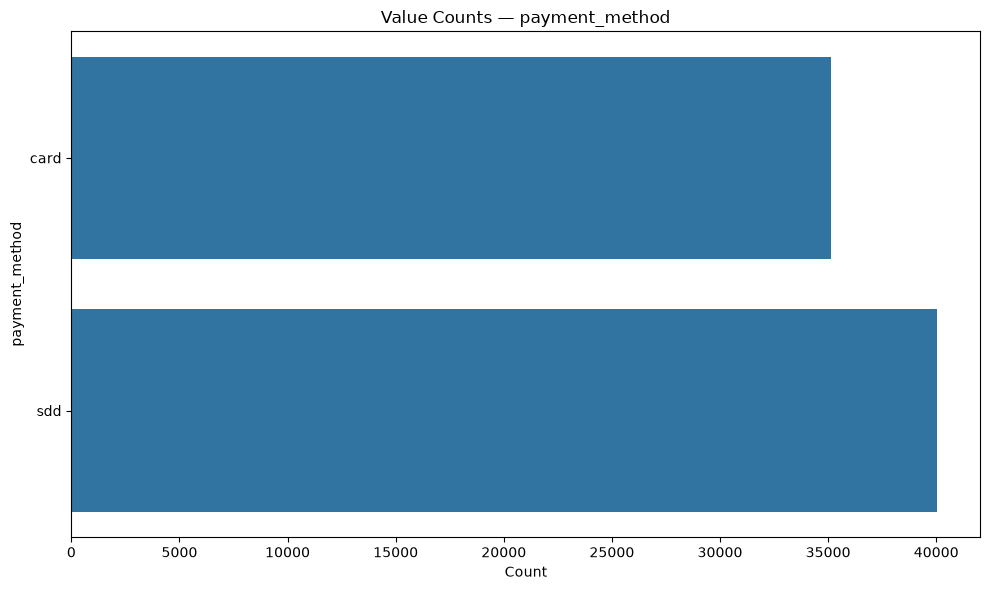

Skipping created_at: 74,612 unique values

####################################################################################################
# EDA: RAW_WALLETS
####################################################################################################
Found 0 numeric columns:

Found 7 categorical columns:
wallet_id, member_id, country, onboarding_method, marketing_channel, status, created_at
Skipping wallet_id: 6,000 unique values
Skipping member_id: 5,534 unique values


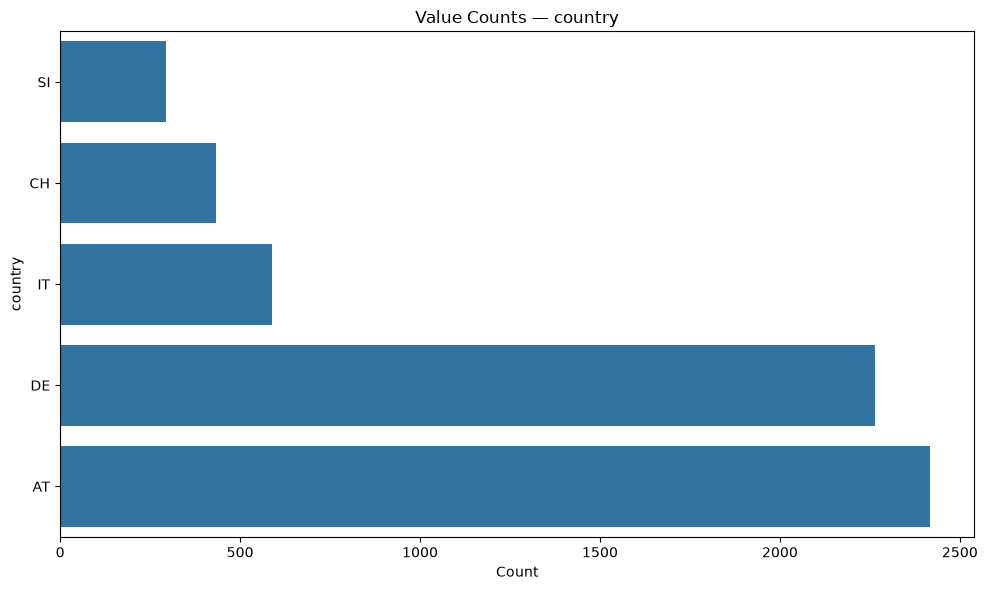

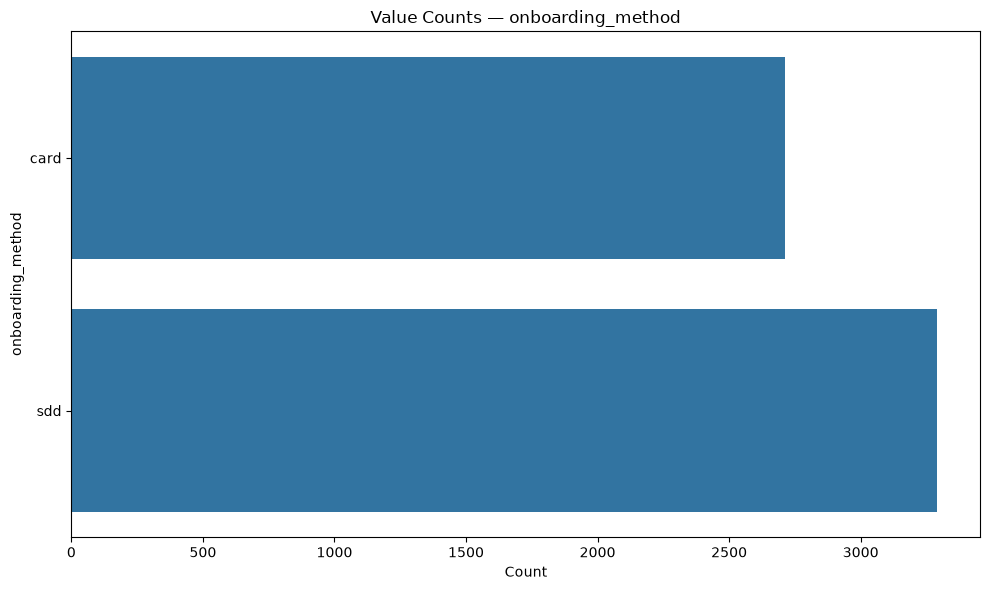

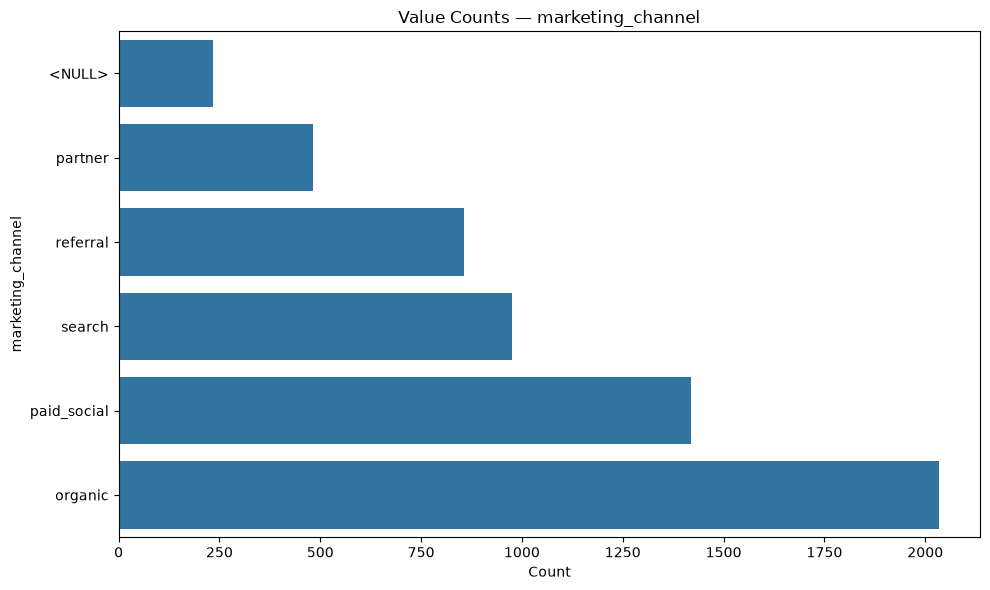

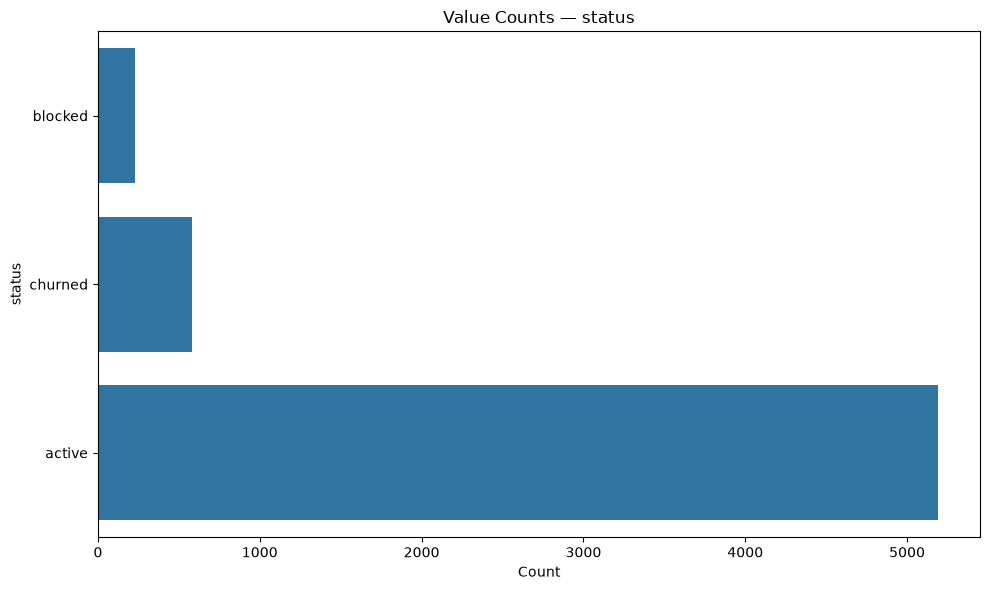

Skipping created_at: 6,000 unique values


In [15]:
for name, df in datasets.items():

    print(f"\n{'#' * 100}")
    print(f"# EDA: {name.upper()}")
    print(f"{'#' * 100}")

    plot_numeric_distributions(df)
    plot_categorical_distributions(df)

In [16]:
def plot_numeric_distributions(df, bins=30):
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

    for col in numeric_cols:
        series = df[col].dropna()

        if series.empty:
            continue

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        sns.histplot(
            series,
            bins=bins,
            kde=True,
            ax=axes[0]
        )

        axes[0].set_title(f"Distribution — {col}")
        axes[0].set_xlabel(col)
        axes[0].set_ylabel("Count")

        sns.boxplot(
            x=series,
            ax=axes[1]
        )

        axes[1].set_title(f"Boxplot — {col}")
        axes[1].set_xlabel(col)

        plt.tight_layout()
        plt.show()

        # Log distribution for strictly positive, right-skewed variables
        if (series > 0).all() and series.skew() > 1:
            plt.figure(figsize=(8, 5))

            sns.histplot(
                np.log1p(series),
                bins=bins,
                kde=True
            )

            plt.title(f"Log Distribution — {col}")
            plt.xlabel(f"log1p({col})")
            plt.ylabel("Count")

            plt.tight_layout()
            plt.show()


####################################################################################################
# EDA: RAW_MERCHANTS
####################################################################################################


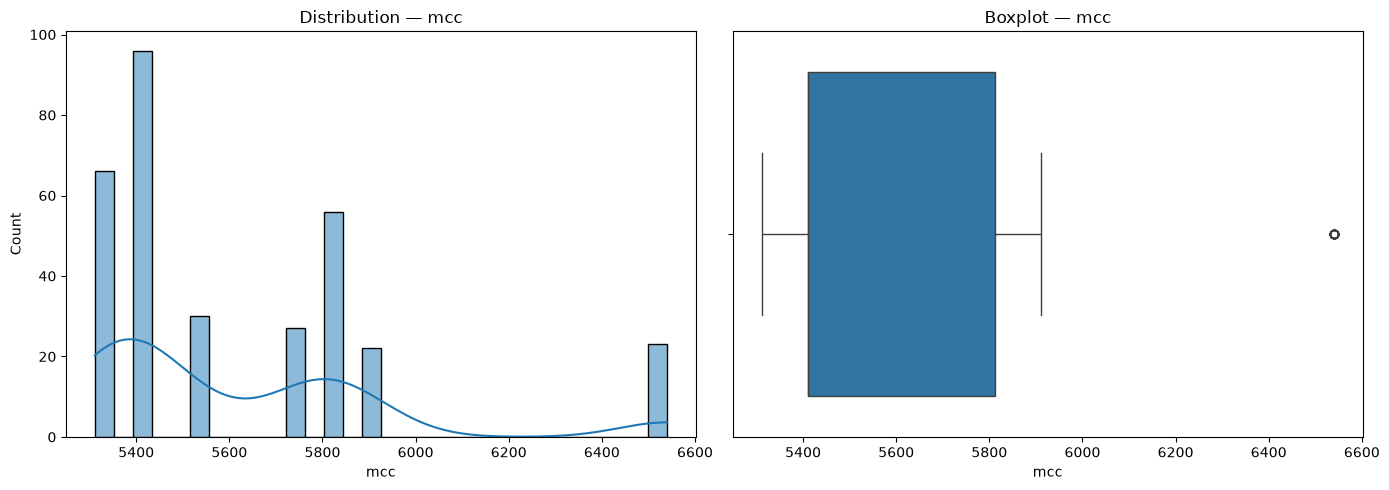

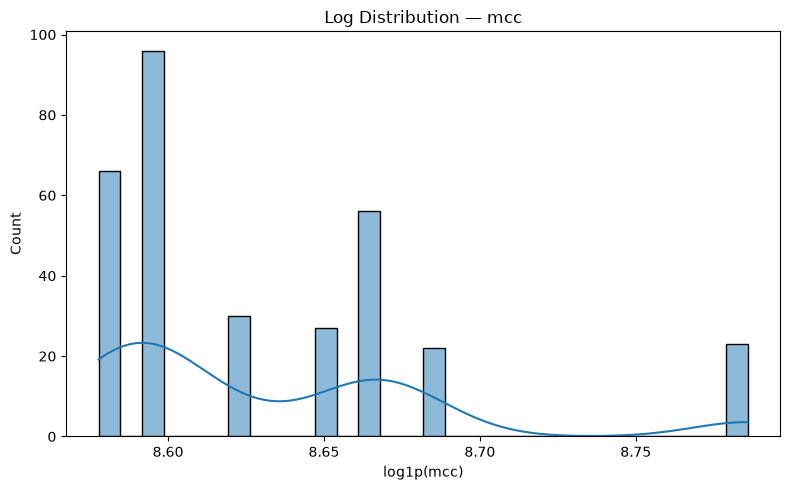


####################################################################################################
# EDA: RAW_TRANSACTIONS
####################################################################################################


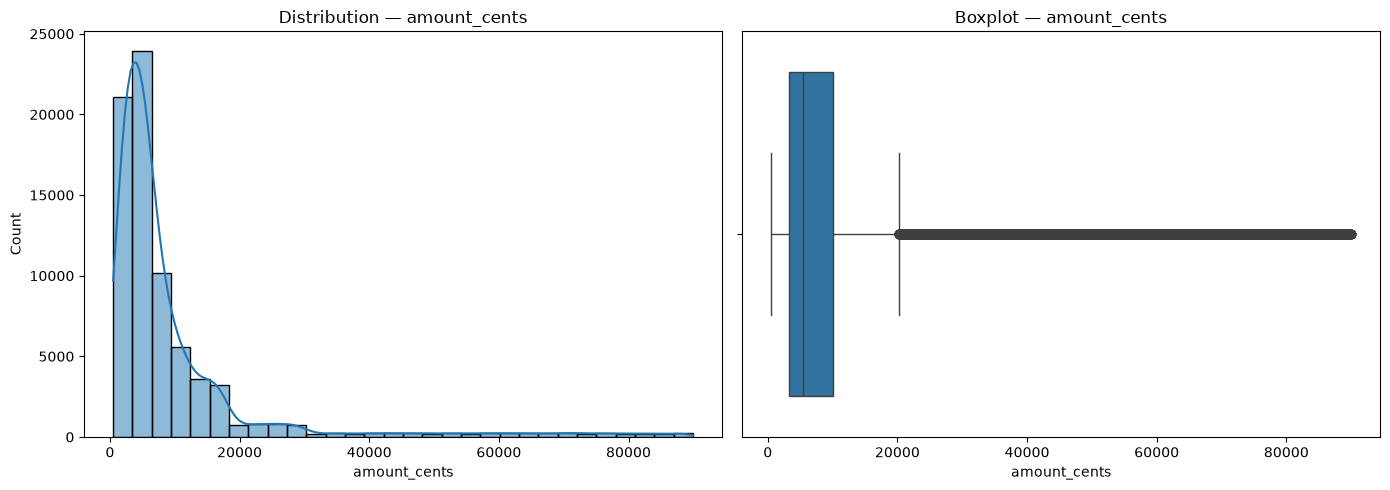

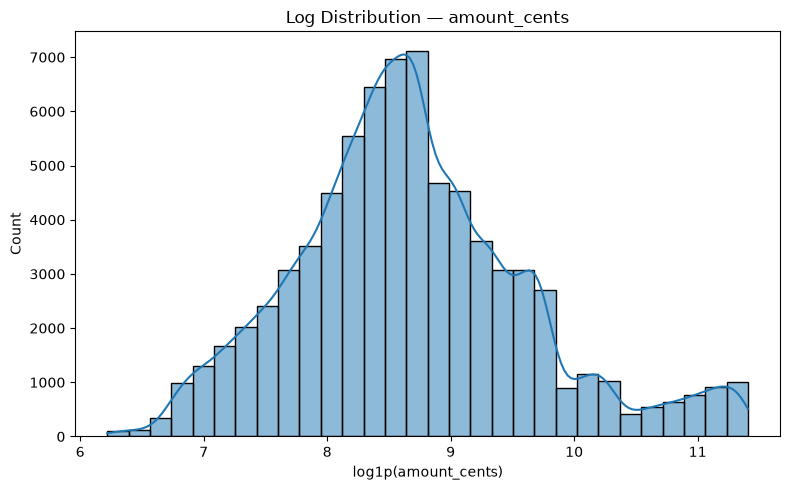


####################################################################################################
# EDA: RAW_WALLETS
####################################################################################################


In [17]:
for name, df in datasets.items():

    print(f"\n{'#' * 100}")
    print(f"# EDA: {name.upper()}")
    print(f"{'#' * 100}")

    plot_numeric_distributions(df)